In [112]:
import pandas as pd 
import numpy as np
from pathlib import Path
from dotenv import dotenv_values
from property_prediction.dataset import get_db_connection
import matplotlib.pyplot as plt
import seaborn as sns
import pymatviz as pmv
import umap

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')
sns.set_context('talk')

**Load and store raw data from PostgreSQL database**

In [33]:
ROOT = Path().resolve().parent
config = dotenv_values(ROOT / ".env")
conn = get_db_connection(config)
db_names = ['materials', 'material_elements', 'properties']
sql = [f"SELECT * from {name}" for name in db_names]

raw_materials_df = pd.read_sql(sql[0], conn)
raw_elements_df = pd.read_sql(sql[1], conn)
raw_properties_df = pd.read_sql(sql[2], conn)

dfs = [raw_materials_df, raw_elements_df, raw_properties_df]



/var/folders/d2/yjlrc0dj6vddrg18pb4b2v3h0000gn/T/ipykernel_26454/1140401245.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_materials_df = pd.read_sql(sql[0], conn)
/var/folders/d2/yjlrc0dj6vddrg18pb4b2v3h0000gn/T/ipykernel_26454/1140401245.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_elements_df = pd.read_sql(sql[1], conn)
/var/folders/d2/yjlrc0dj6vddrg18pb4b2v3h0000gn/T/ipykernel_26454/1140401245.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_properties_df = pd.read_sql(sql[2], conn)


**Validating Data**

In [34]:
for i, df in enumerate(dfs):
    shape = df.shape
    null_count = df.isnull().sum()
    null_count = null_count[null_count > 0] if len(null_count[null_count > 0]) else 'None'
    duplicate_entries = df.duplicated().sum()
    print(
        f"""{db_names[i]} Database \n\nShape: {shape} \n\nNull values: \n{null_count} \n\nDuplicate Entries: {duplicate_entries}"""
    )
    print("-" * 40)



materials Database 

Shape: (163211, 12) 

Null values: 
energy_above_hull    8838
dtype: int64 

Duplicate Entries: 0
----------------------------------------
material_elements Database 

Shape: (571375, 3) 

Null values: 
None 

Duplicate Entries: 0
----------------------------------------
properties Database 

Shape: (489633, 8) 

Null values: 
value    167813
dtype: int64 

Duplicate Entries: 0
----------------------------------------


In [35]:
for i, df in enumerate(dfs):
    print(f"{db_names[i]} Database \n")
    print(df.dtypes)
    print('-' * 40)


materials Database 

material_id                     str
formula_pretty                  str
crystal_system                  str
spacegroup_symbol               str
spacegroup_number             int64
volume                      float64
nsites                        int64
nelements                     int64
is_stable                      bool
energy_above_hull           float64
s3_key                          str
ingested_at          datetime64[us]
dtype: object
----------------------------------------
material_elements Database 

material_id            str
element_symbol         str
atomic_fraction    float64
dtype: object
----------------------------------------
properties Database 

id                        int64
material_id                 str
property_name               str
value                   float64
unit                        str
functional                  str
source                      str
created_at       datetime64[us]
dtype: object
-----------------------------------

In [178]:
joined_df = raw_materials_df.merge(raw_properties_df, on='material_id').merge(raw_elements_df, on='material_id')
joined_df = joined_df[['material_id', 'crystal_system', 'is_stable',
       'energy_above_hull', 'property_name',
       'value', 'unit', 'element_symbol',
       'atomic_fraction']]
band_gap_df = joined_df[joined_df.property_name == "band_gap"].drop(columns=['property_name'])
formation_energy_df = joined_df[joined_df.property_name == "formation_energy_per_atom"].drop(columns=['property_name'])

bulk_modulus_df = joined_df[joined_df.property_name == "bulk_modulus"] 


**Data Quality**

Text(0, 0.5, 'Null Count')

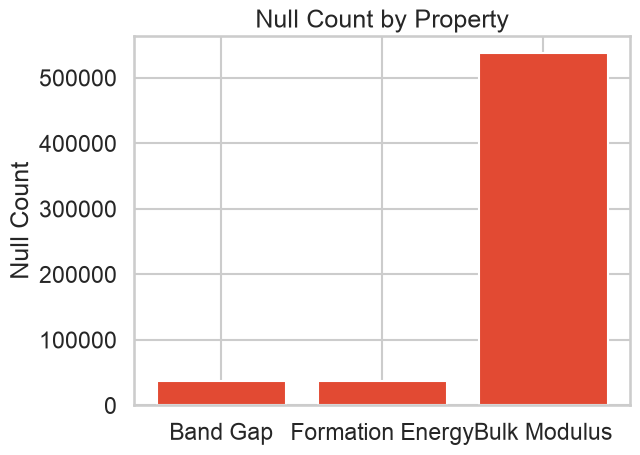

In [179]:
names = ['Band Gap', 'Formation Energy', 'Bulk Modulus']
dfs = [band_gap_df, formation_energy_df, bulk_modulus_df]
null_count = []
for df in dfs:
    null_count.append(int(df['value'].isna().sum()))
plt.bar(names, null_count)
plt.title("Null Count by Property")
plt.ylabel("Null Count")

**Property Distributions**

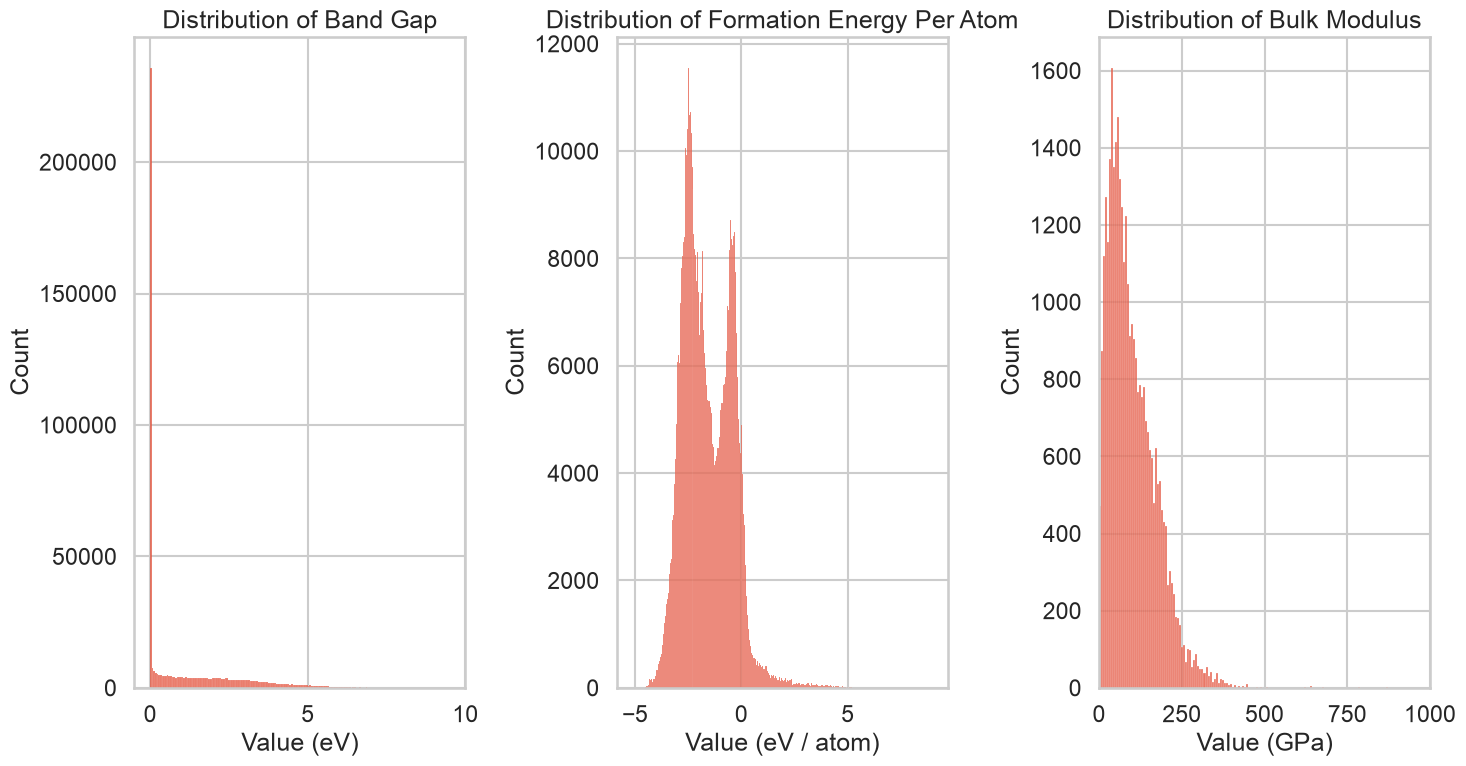

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Generate band-gap histogram
sns.histplot(band_gap_df.dropna(subset='value'), x = 'value', ax=axes[0])
axes[0].set_xlim(-0.5, 10)
axes[0].set_title("Distribution of Band Gap")
axes[0].set_xlabel("Value (eV)")

# Generate formation energy histogram
sns.histplot(formation_energy_df.dropna(subset='value'), x = 'value', ax=axes[1])
axes[1].set_title("Distribution of Formation Energy Per Atom")
axes[1].set_xlabel("Value (eV / atom)")

bulk_modulus_df = bulk_modulus_df[bulk_modulus_df['value'].between(0, 1000)]
sns.histplot(bulk_modulus_df.dropna(subset='value'), x = 'value', ax=axes[2])
axes[2].set_xlim(0, 1000)
axes[2].set_title("Distribution of Bulk Modulus")
axes[2].set_xlabel("Value (GPa)")
plt.tight_layout()

**Crystal System Analysis**

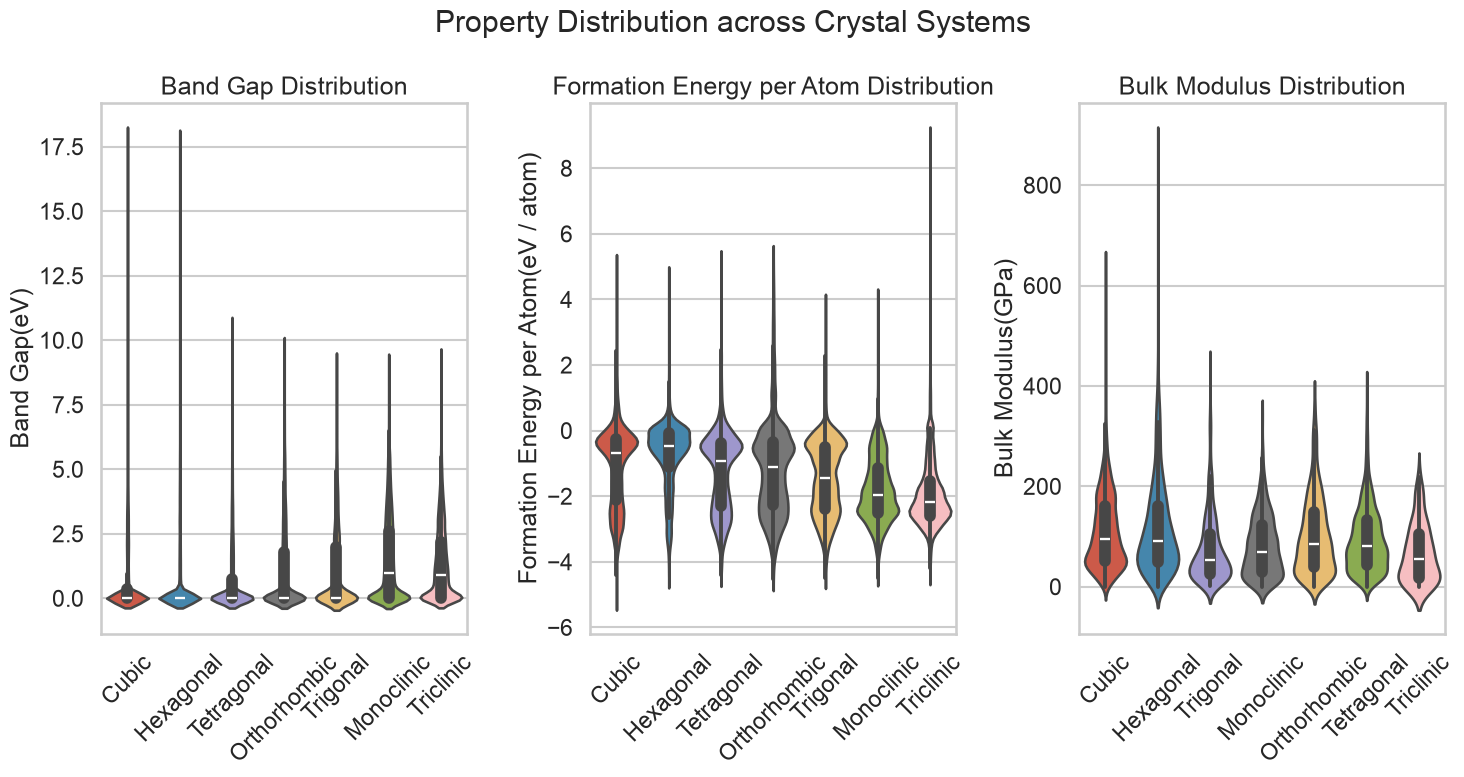

In [72]:
dfs = [band_gap_df, formation_energy_df, bulk_modulus_df]
names = ['Band Gap', 'Formation Energy per Atom', 'Bulk Modulus']
units = ['eV', 'eV / atom', 'GPa']
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
plt.suptitle('Property Distribution across Crystal Systems')
for i, df in enumerate(dfs):
        sns.violinplot(data=dfs[i], x='crystal_system', y='value', hue='crystal_system', ax=axes[i], legend=False)
        axes[i].set_title(names[i] + " Distribution")
        axes[i].set_ylabel(names[i] + f"({units[i]})")
        axes[i].set_xlabel(None)
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()


**Energy Above Hull Distribution**

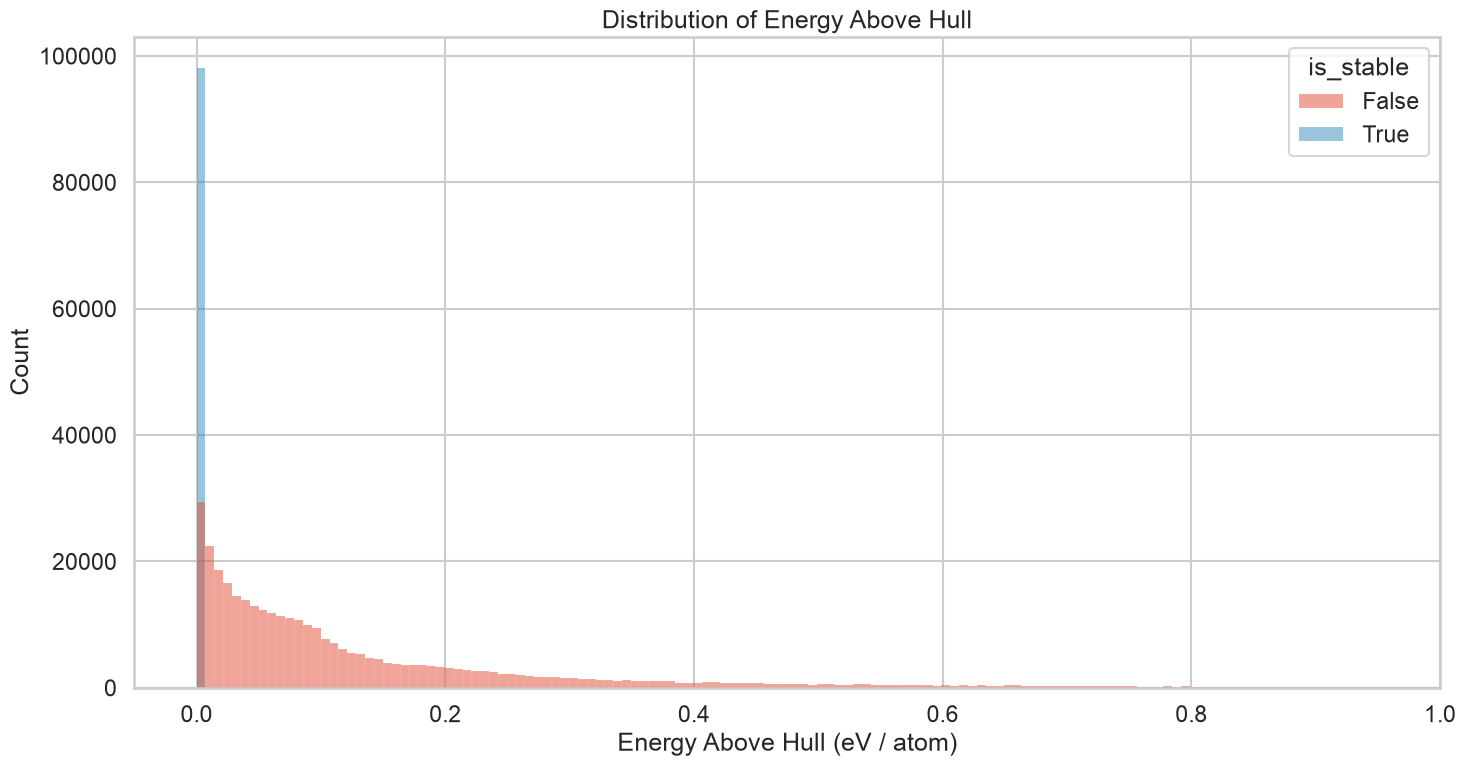

In [73]:
plt.figure(figsize=(15, 8))
sns.histplot(data=joined_df, x='energy_above_hull', hue='is_stable')
plt.xlim(-0.05, 1)
plt.title("Distribution of Energy Above Hull")
plt.xlabel("Energy Above Hull (eV / atom)")
plt.tight_layout()

**Formation Energy vs. Energy Above Hull**

<Axes: title={'center': 'Formation Energy per Atom vs. Energy Above Hull'}, xlabel='Energy Above Hull (eV / atom)', ylabel='Formation Energy per Atom (eV / atom)'>

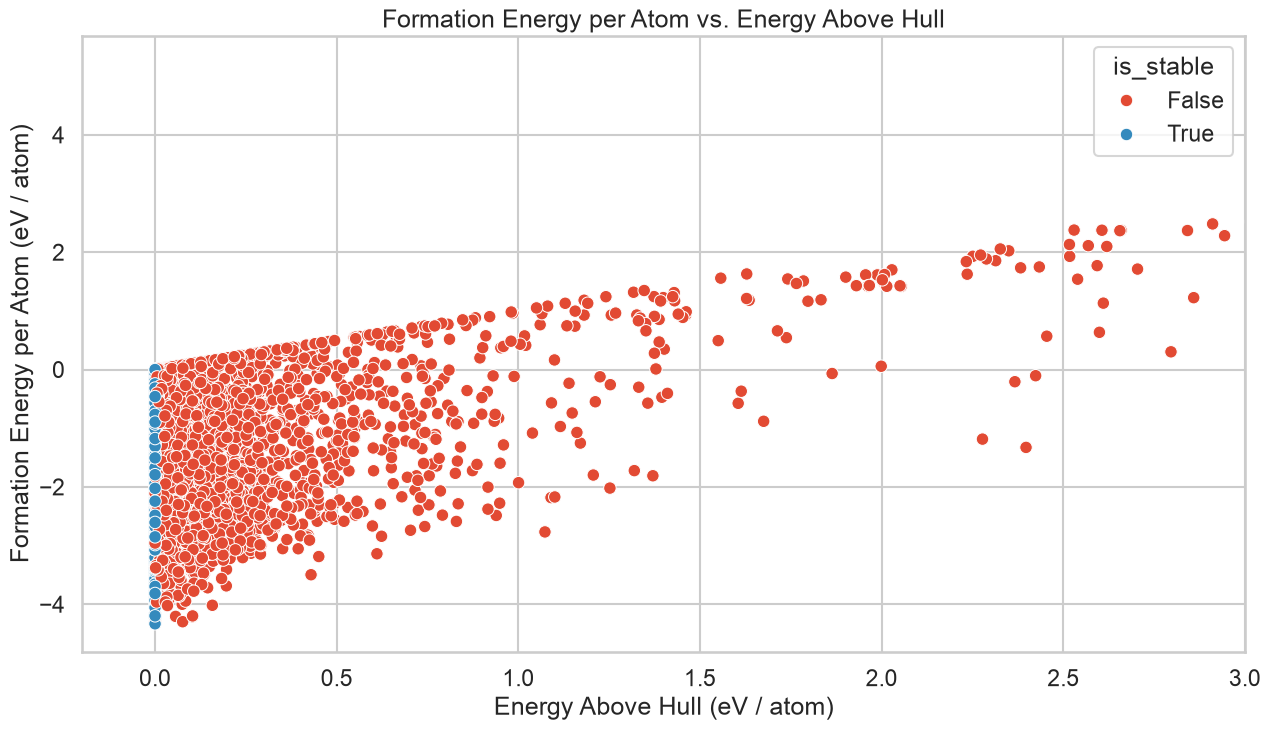

In [75]:
plt.figure(figsize=(15,8))
plt.xlim(-0.2, 3)
plt.title("Formation Energy per Atom vs. Energy Above Hull")
plt.xlabel("Energy Above Hull (eV / atom)")
plt.ylabel("Formation Energy per Atom (eV / atom)")
sns.scatterplot(formation_energy_df.sample(n=5000), x='energy_above_hull', y='value', hue='is_stable')


In [87]:

band_gap_df_mean = band_gap_df.groupby('element_symbol', as_index=False).agg({
    'element_symbol' : 'first',
    'value' : 'mean',
})

formation_energy_df_mean = formation_energy_df.groupby('element_symbol', as_index=False).agg({
    'element_symbol' : 'first',
    'value' : 'mean',
})



band_gap_averages = dict(zip(band_gap_df_mean['element_symbol'], band_gap_df_mean['value']))
formation_energy_averages = dict(zip(formation_energy_df_mean['element_symbol'], formation_energy_df_mean['value']))



In [88]:
pmv.ptable_heatmap(band_gap_averages, colorbar=dict(title="Band Gap (eV)"))


In [89]:
pmv.ptable_heatmap(formation_energy_averages, colorbar=dict(title="Formation Energy per Atom (eV / atom)"))

**Correlations**


       material_id  Band Gap Symbol  Formation Energy  Bulk Modulus
0       mp-1185318    0.0000     Li         -0.317595           NaN
1       mp-1185318    0.0000     Ge         -0.317595           NaN
2       mp-1185318    0.0000     Ir         -0.317595           NaN
3       mp-1185319    6.6467     Li         -2.136924           NaN
4       mp-1185319    6.6467     Cl         -2.136924           NaN
...            ...       ...    ...               ...           ...
571370  mp-2933735    0.0000     Cu         -0.417576         8.166
571371  mp-2933735    0.0000      O         -0.417576         8.166
571372  mp-2936049       NaN     Mn               NaN           NaN
571373  mp-2936049       NaN     Sb               NaN           NaN
571374  mp-2936049       NaN      O               NaN           NaN

[571375 rows x 5 columns]


<Axes: xlabel='Band Gap', ylabel='Bulk Modulus'>

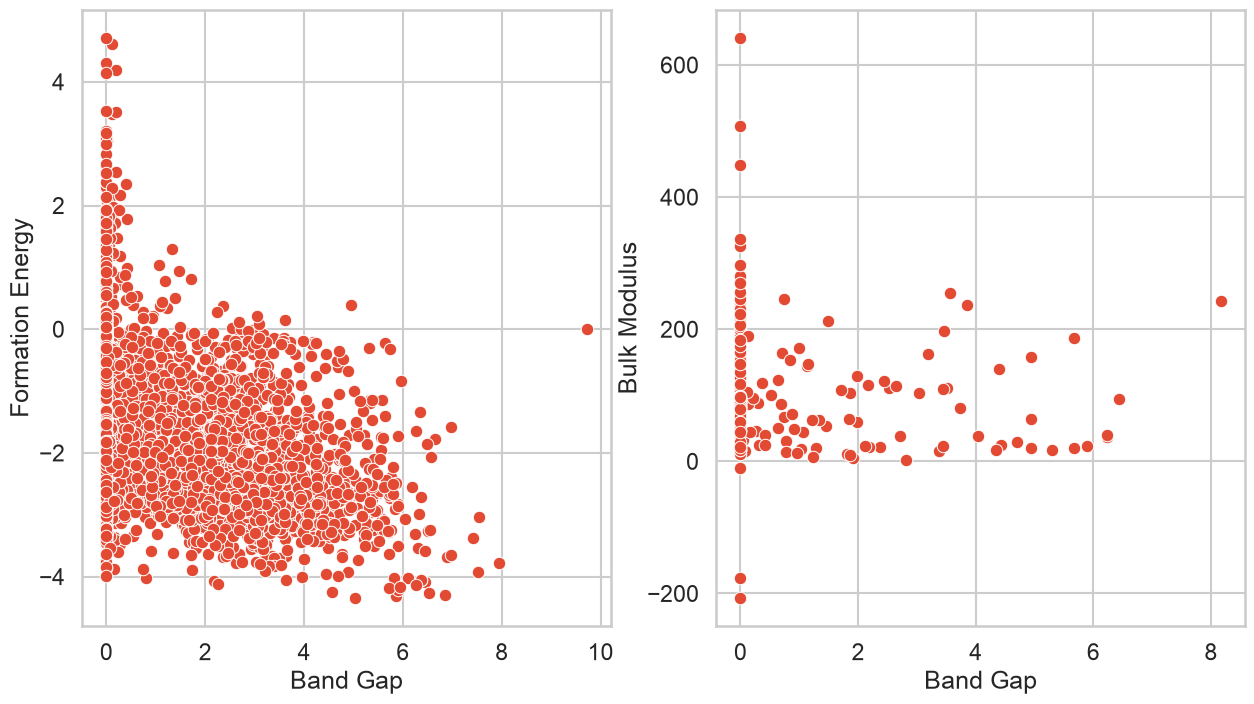

In [187]:
simple_band_gap_df = band_gap_df[['material_id',
       'value', 'element_symbol']]
simple_band_gap_df.columns = ['material_id', 'Band Gap', 'Symbol']

simple_formation_energy_df = formation_energy_df[['material_id',
       'value', 'element_symbol']]
simple_formation_energy_df.columns = ['material_id', 'Formation Energy', 'Symbol']

simple_bulk_modulus_df = bulk_modulus_df[['material_id',
       'value', 'element_symbol']]
simple_bulk_modulus_df.columns = ['material_id', 'Bulk Modulus', 'Symbol']


correlation_df = simple_band_gap_df.merge(simple_formation_energy_df, on=['material_id', 'Symbol']).merge(simple_bulk_modulus_df, on=['material_id', 'Symbol'])
print(correlation_df)
fig, axes = plt.subplots(1, 2, figsize=(15,8))
sns.scatterplot(data=correlation_df.sample(5000), x='Band Gap', y='Formation Energy', ax=axes[0])
sns.scatterplot(data=correlation_df.sample(5000), x='Band Gap', y='Bulk Modulus', ax=axes[1])

<Axes: >

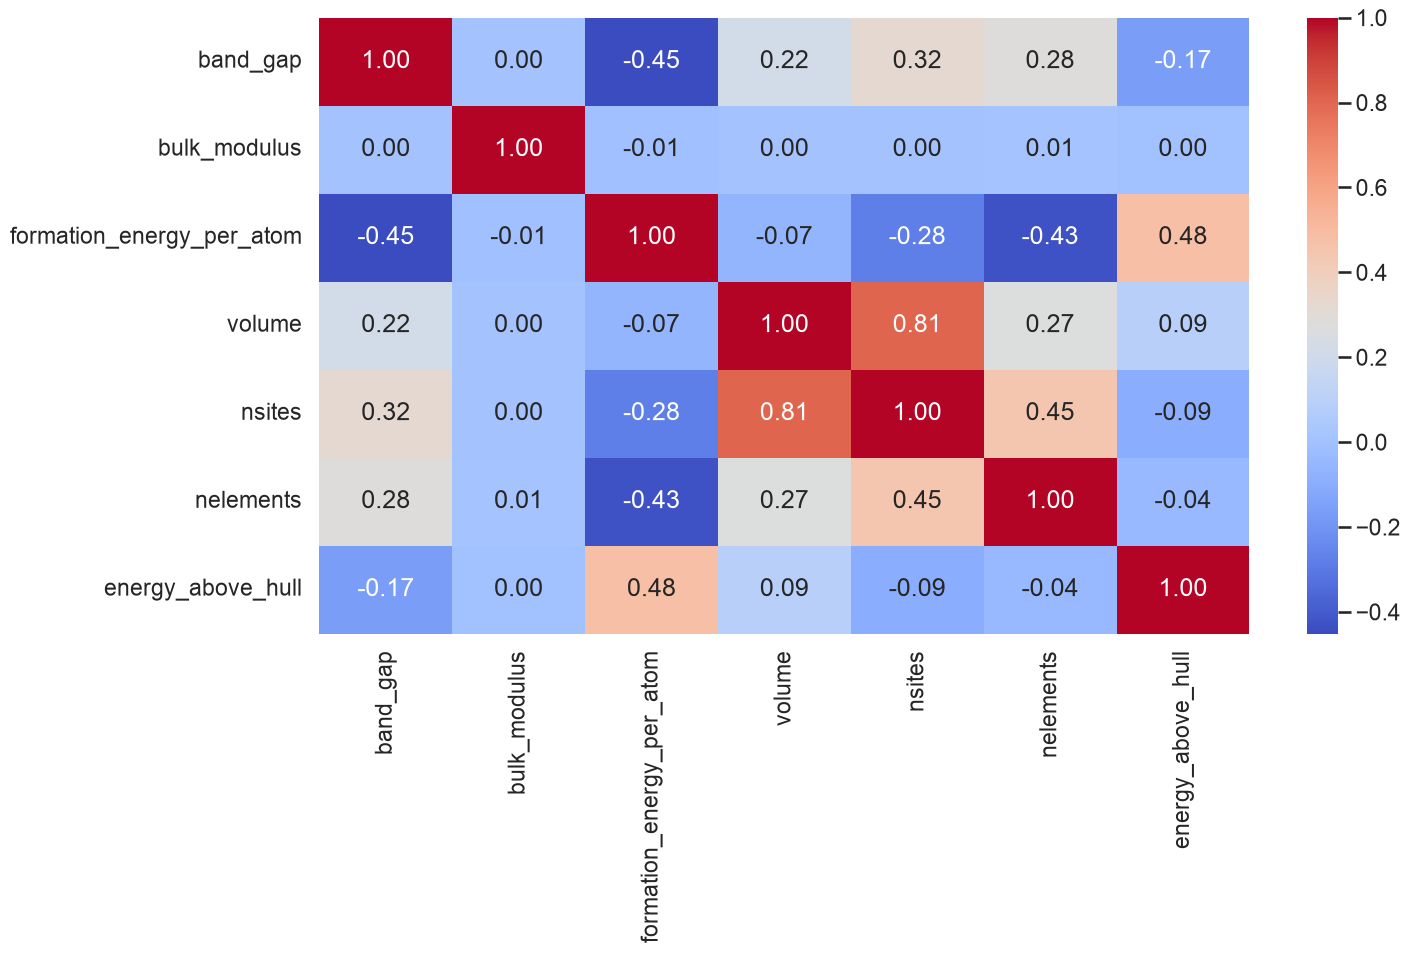

In [191]:
plt.figure(figsize=(15,8))
properties_pivot_df = raw_properties_df.pivot_table(index='material_id', columns='property_name', values='value').reset_index()
corr_df = properties_pivot_df.merge(raw_materials_df[['material_id', 'volume', 'nsites', 'nelements', 'energy_above_hull']], on='material_id').drop(columns='material_id')
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [119]:
elements_pivot_df = raw_elements_df.pivot_table(index='material_id', columns='element_symbol', values='atomic_fraction', fill_value=0)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(elements_pivot_df.values)

/Users/aprakash/general/materials_property_prediction/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/aprakash/general/materials_property_prediction/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/aprakash/general/materials_property_prediction/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/aprakash/general/materials_property_prediction/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning:

**UMAP**

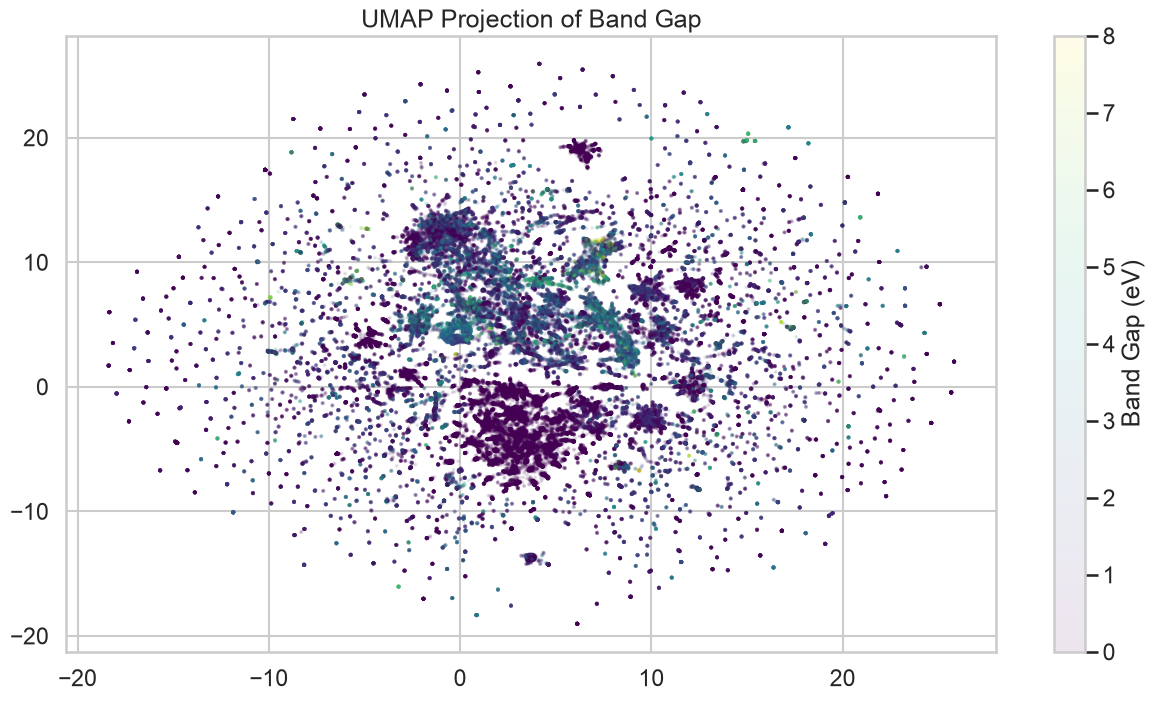

In [164]:
umap_df = pd.DataFrame(embedding, columns = ['UMAP_1', 'UMAP_2'])
umap_df['material_id'] = elements_pivot_df.index.values
umap_df = umap_df.merge(properties_pivot_df, on='material_id')

plot_df = umap_df.dropna(subset=['band_gap'])
plt.figure(figsize=(15, 8))
scatter = plt.scatter(plot_df['UMAP_1'], plot_df['UMAP_2'], c=plot_df['band_gap'], cmap='viridis', alpha=0.1, s=2, vmin=0, vmax=8)
cbar = plt.colorbar(scatter)
plt.title("UMAP Projection of Band Gap")
cbar.set_label('Band Gap (eV)')

plt.show()

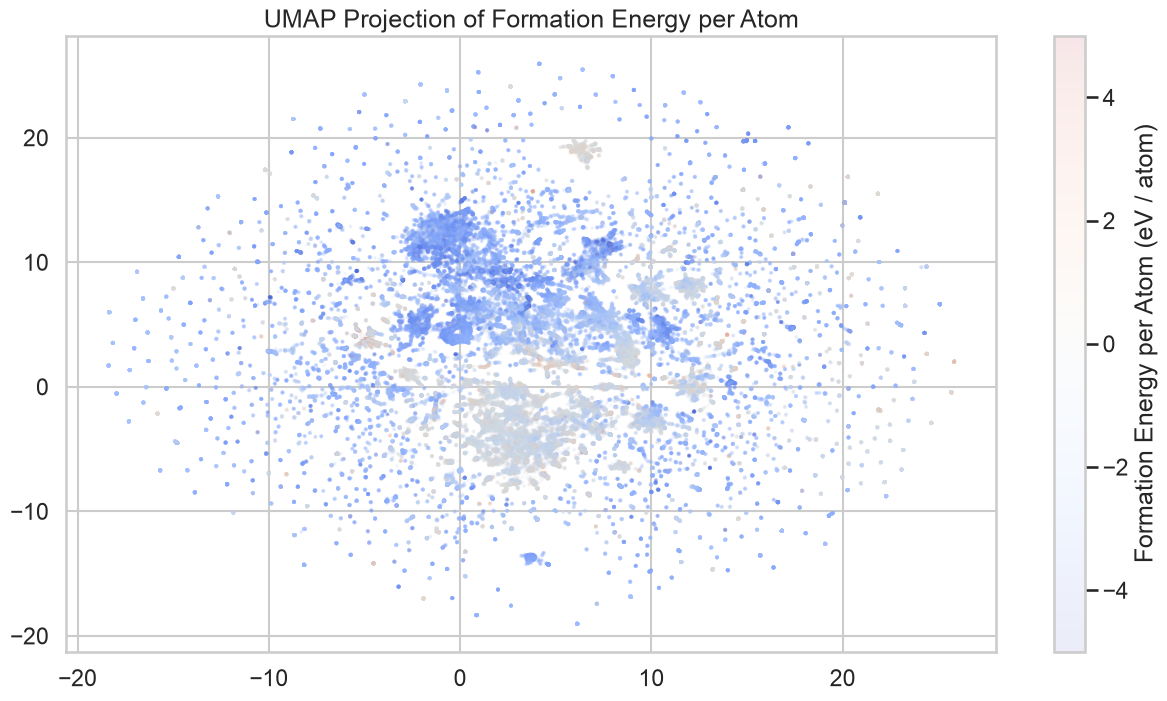

In [165]:
plot_df = umap_df.dropna(subset=['formation_energy_per_atom'])
plt.figure(figsize=(15, 8))
scatter = plt.scatter(plot_df['UMAP_1'], plot_df['UMAP_2'], c=plot_df['formation_energy_per_atom'], cmap='coolwarm', alpha=0.1, s=2, vmin=-5, vmax=5)
cbar = plt.colorbar(scatter)
cbar.set_label('Formation Energy per Atom (eV / atom)')
plt.title('UMAP Projection of Formation Energy per Atom')
plt.show()

In [ ]:
conn.close()